# Prompt chaining linear Worklfow
- Its called as prompt chaining because multiple LLMs are involved
- The workflow involves creation of a blog, where 1 LLM is responsible to generate content given the topic and another LLM is responsible for restructuring the content in the form of a blog
- Flow:
    - START -> LLM1 (Content Generation) -> LLM2 (Restructuring) -> END

In [14]:
from langchain_groq import ChatGroq
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# State Creation

In [15]:
class State(TypedDict):
    topic: str
    content: str
    blog: str


# Create Graph

In [16]:
graph = StateGraph(State)


# Defining the node functions

In [17]:
def llm_content_generation(state: State) -> State:

    llm = ChatGroq(model="qwen/qwen3-32b")
    
    topic = state["topic"]
    prompt = f"""You are a content creator. Create content for the given topic:{topic}"""

    response = llm.invoke(prompt)
    state["content"] = response.content

    return state

def llm_restructuring(state: State) -> State:

    llm = ChatGroq(model="qwen/qwen3-32b")

    content = state["content"]
    prompt = f"""You are a blog restructurer. Restructure the given content: {content} in a structured manner"""

    response = llm.invoke(prompt)
    state["blog"] = response.content

    return state

# Adding Nodes

In [18]:
graph.add_node("llm1", llm_content_generation)
graph.add_node("llm2", llm_restructuring)


# Add edges
- START -> LLM1 -> LLM2 -> END

In [19]:
graph.add_edge(START,"llm1")
graph.add_edge("llm1", "llm2")
graph.add_edge("llm2", END)


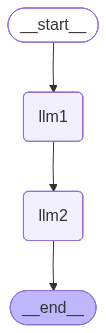

In [20]:

# Compile the graph
workflow = graph.compile()

workflow

# Invoking the graph

In [21]:
initial_state = {"topic": "LangGraph"}
final_state = workflow.invoke(initial_state)
final_state

{'topic': 'LangGraph',
 'content': '<think>\nOkay, the user wants me to create content about LangGraph. Let me start by understanding what LangGraph is. I remember that LangGraph is a framework for building stateful, workflow-based applications using large language models (LLMs). It\'s part of the LangChain ecosystem, right? So, I should explain its key features, use cases, and maybe how it compares to other tools.\n\nFirst, I need to define LangGraph. It\'s a tool for creating complex applications by combining LLMs with workflows and state management. Then, the main components: nodes (like different functions or LLMs), edges (decisions based on input), and state management. Maybe give an example of a simple workflow, like a customer service chatbot.\n\nUse cases are important. The user might be interested in real-world applications. Possible examples include customer service automation, data processing pipelines, and interactive applications. I should also mention how it\'s different 

### The advantages of using Graphs is that we have access to the intermediate results too as we maintain the state